In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [3]:
# 1. Initialize the Sequential model
model = models.Sequential()

# 2. Input Layer: Flatten the 8x8 images into 64 features
model.add(layers.Flatten(input_shape=(8, 8)))

# 3. Hidden Layer 1: 64 -> 32 neurons
model.add(layers.Dense(32, activation='relu'))

model.add(layers.Dense(32, activation='relu'))

# 4. Hidden Layer 2: 32 -> 16 neurons
model.add(layers.Dense(16, activation='relu'))

# 5. Output Layer: 16 -> 4 neurons
# Use 'softmax' for multi-class probability distribution
model.add(layers.Dense(4, activation='softmax'))

# 6. Compile: Use Categorical Crossentropy for one-hot labels
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Show the summary (it will confirm the total params)
model.summary()

g:\Studia workspace\KOSP\projekt\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,732 (14.58 KB)

 Trainable params: 3,732 (14.58 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
def prepare_data(x):
    #med_filtered_frame = scipy.signal.medfilt(x, kernel_size=3)
    x_normalized = x / 255.0 if x.max() > 1.0 else x

    # 2. Apply threshold (0.5) and cast to integer
    x_binarized = (x_normalized > 0.5).astype(np.float32)
    return x_normalized

# Load the archive
test_data = np.load('arrows8_keras_format.npz')

# List the keys to see what's inside
print("Keys in file:", test_data.files)

# Extract images and labels (replace 'x_test'/'y_test' with your actual keys)
x_train = test_data['x_train']
y_train = test_data['y_train']

x_val = test_data['x_val']
y_val = test_data['y_val']

x_test = test_data['x_test']
y_test = test_data['y_test']

x_train = prepare_data(x_train)
x_val = prepare_data(x_val)
x_test = prepare_data(x_test)

print(f"Test data shape: {x_test.shape}")



Keys in file: ['x_train', 'y_train', 'x_val', 'y_val', 'x_test', 'y_test', 'class_names']
Test data shape: (4078, 8, 8, 1)


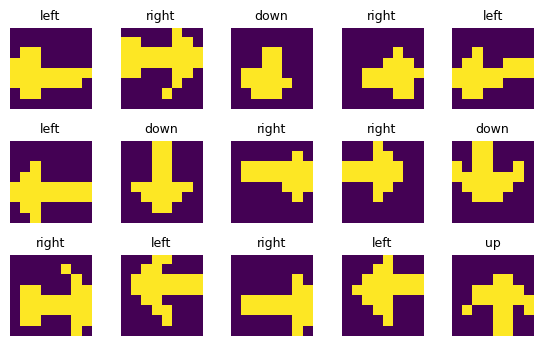

In [5]:
def display_gray_grid(x_test, y_test):
    # 'facecolor' sets the background color of the whole window
    fig = plt.figure(figsize=(7, 4)) 
    
    for i in range(15):
        # Set the background for each individual subplot
        ax = plt.subplot(3, 5, i + 1)
        
        img = np.squeeze(x_test[i])
        true_label = y_test.flatten()[i]
        named_label = ["up", "left", "down", "right"][true_label]
        
        # Display image
        plt.imshow(img, cmap='viridis', interpolation='nearest')
        
        # Change text color to white so it's visible on the gray background
        plt.title(f"{named_label}", fontsize=9)
        plt.axis('off')
    
    plt.subplots_adjust(wspace=0.1, hspace=0.4)
    plt.show()

# Call the function
display_gray_grid(x_val, y_val)

In [6]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # reduce LR by 50%
    patience=50,       # wait 15 epochs with no improvement
    min_lr=1e-7
)

# If your y_train is one-hot (4274, 4), this works perfectly:
history = model.fit(x_train, y_train, 
                    epochs=20, 
                    batch_size=32, 
                    validation_data=(x_val, y_val), 
                    verbose=1,
                    callbacks = [])

Epoch 1/20


134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7134 - loss: 0.8127 - val_accuracy: 0.8700 - val_loss: 0.4223
Epoch 2/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9202 - loss: 0.2666 - val_accuracy: 0.9423 - val_loss: 0.1805
Epoch 3/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9705 - loss: 0.1123 - val_accuracy: 0.9809 - val_loss: 0.0828
Epoch 4/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9899 - loss: 0.0529 - val_accuracy: 0.9918 - val_loss: 0.0441
Epoch 5/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9963 - loss: 0.0290 - val_accuracy: 0.9965 - val_loss: 0.0267
Epoch 6/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9979 - loss: 0.0188 - val_accuracy: 0.9963 - val_loss: 0.0191
Epoch 7/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9984 - loss: 0.0124 - val_accuracy: 0.9968 - val_loss: 0.0164
Epoch 8/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9991 - loss: 0.0087 - val_accuracy: 0.9973 - val_

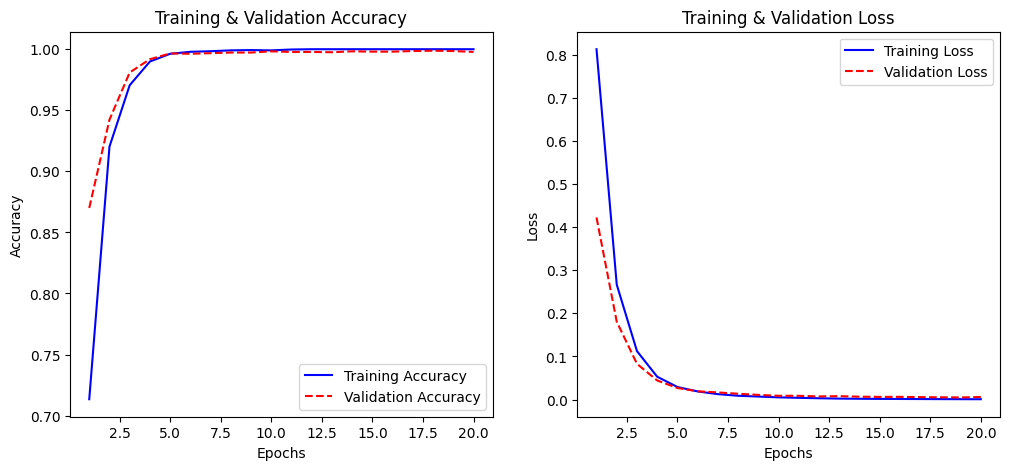

In [7]:
import matplotlib.pyplot as plt
def plot_history(history):
    # Plot Training & Validation Accuracy / Loss
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    epochs = range(1, len(acc) + 1)
    # Plot Accuracy
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # Plot Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
plot_history(history.history)

128/128 - 0s - 1ms/step - accuracy: 0.9993 - loss: 0.0038

Test Accuracy: 99.93%
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


<Figure size 1000x1000 with 0 Axes>

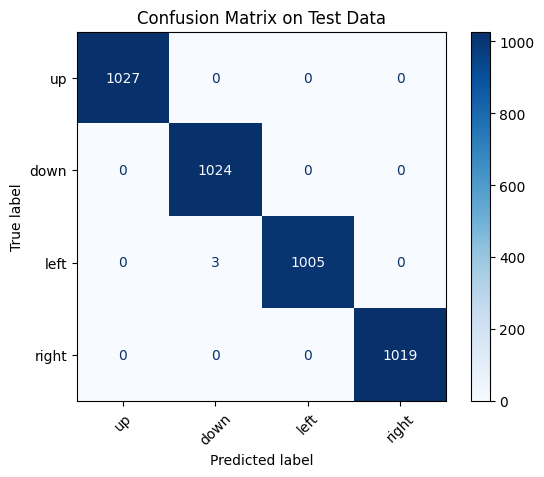

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#Evaluate the model on test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

#Confusion Matrix
y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)
class_names = ['up', 'down', 'left', 'right']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(10,10))
disp.plot(cmap='Blues', xticks_rotation=45, values_format='d')
plt.title("Confusion Matrix on Test Data")
plt.show()

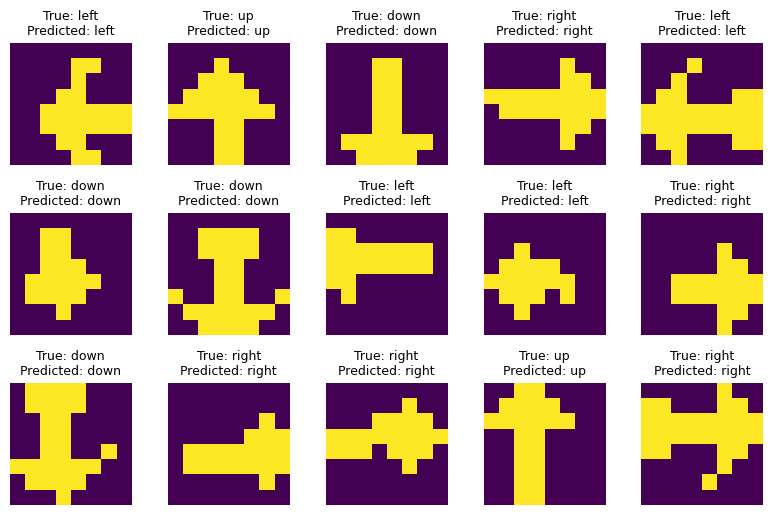

In [9]:
def display_pred_grid(x_test, y_test, predicted_labels):
    # 'facecolor' sets the background color of the whole window
    fig = plt.figure(figsize=(10, 6)) 
    
    for i in range(15):
        # Set the background for each individual subplot
        ax = plt.subplot(3, 5, i + 1)
        
        img = np.squeeze(x_test[i])
        true_label = y_test.flatten()[i]
        named_label = ["up", "left", "down", "right"][true_label]
        predicted_label = predicted_labels[i]
        named_predicted_label = ["up", "left", "down", "right"][predicted_label]
        
        # Display image
        plt.imshow(img, cmap='viridis', interpolation='nearest')
        
        # Change text color to white so it's visible on the gray background
        plt.title(f"True: {named_label}\nPredicted: {named_predicted_label}", fontsize=9)
        plt.axis('off')
    
    plt.subplots_adjust(wspace=0.1, hspace=0.4)
    plt.show()

# Call the function
display_pred_grid(x_test, y_test, y_pred)

In [12]:
model.save('wedrowiec-pre_hls.h5')